#**#PHASE 1 — Dataset Preparation**

In [2]:
import pandas as pd

In [26]:
# Load raw parts without headers
df1 = pd.read_csv("UNSW-NB15_1.csv", header=None)
df2 = pd.read_csv("UNSW-NB15_2.csv", header=None)
df3 = pd.read_csv("UNSW-NB15_3.csv", header=None)
df4 = pd.read_csv("UNSW-NB15_4.csv", header=None)

/tmp/ipython-input-6018/3808097420.py:2: DtypeWarning: Columns (1,3,47) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv("UNSW-NB15_1.csv", header=None)
/tmp/ipython-input-6018/3808097420.py:3: DtypeWarning: Columns (3,39,47) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv("UNSW-NB15_2.csv", header=None)


In [28]:
# Merge all
train = pd.concat([df1, df2, df3, df4], ignore_index=True)

In [29]:
#Rename last column as label
train = train.rename(columns={train.columns[-1]: 'label'})

In [30]:
#converstion to binary classification
train['label'] = train['label'].apply(lambda x: 0 if x == 0 else 1)

In [8]:
train.head()

,0,1,2,3,4,5,6,7,8,9,...,39,40,41,42,43,44,45,46,47,label
0,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132,164,31,...,0,3,7,1,3,1,1,1,NaN,0
1,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,...,0,2,4,2,3,1,1,2,NaN,0
2,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,...,0,12,8,1,2,2,1,1,NaN,0
3,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,...,0,6,9,1,1,1,1,1,NaN,0
4,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,...,0,7,9,1,1,1,1,1,NaN,0


#**#PHASE 2 — Data Cleaning & Preprocessing**

In [31]:
#Drop IP Address Columns
train = train.drop(columns=[0, 2])

In [32]:
#Encode Categorical Columns
from sklearn.preprocessing import LabelEncoder

categorical_cols = train.select_dtypes(include='object').columns

le = LabelEncoder()

for col in categorical_cols:
    # Convert the column to string type before encoding to handle mixed types
    train[col] = train[col].astype(str)
    train[col] = le.fit_transform(train[col])

In [34]:
#reduce dataset size
train = train.sample(n=300000, random_state=42)

# **#PHASE 3 — Feature Engineering**

In [35]:
#separate Feature and Target
X = train.drop(columns=['label'])
y = train['label']

In [36]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [37]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **#PHASE 4-MODEL TRAINING**

In [38]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.1, random_state=42)
model.fit(X_train)

IsolationForest(contamination=0.1, random_state=42)

#**PHASE 5 — Prediction & Evaluation**

In [42]:
#Predict Anomalies
y_pred = model.predict(X_test)

# Convert -1 to 1 (anomaly), 1 to 0 (normal)
y_pred = np.where(y_pred == -1, 1, 0)

In [43]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

roc = roc_auc_score(y_test, y_pred)
print("ROC-AUC Score:", roc)

[[73278  5319]
 [ 7950  3453]]
              precision    recall  f1-score   support

           0       0.90      0.93      0.92     78597
           1       0.39      0.30      0.34     11403

    accuracy                           0.85     90000
   macro avg       0.65      0.62      0.63     90000
weighted avg       0.84      0.85      0.84     90000

ROC-AUC Score: 0.6175703549780921


# **#METHOD 1 — PCA 2D Scatter Plot (Most Popular)**

In [50]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer # Import SimpleImputer

pca = PCA(n_components=2)

# Impute NaN values in X_test before applying PCA
# Instantiate SimpleImputer with a strategy, e.g., mean
imputer = SimpleImputer(strategy='mean')

# Fit and transform X_test to handle NaNs
X_test_imputed = imputer.fit_transform(X_test)

X_test_2d = pca.fit_transform(X_test_imputed)

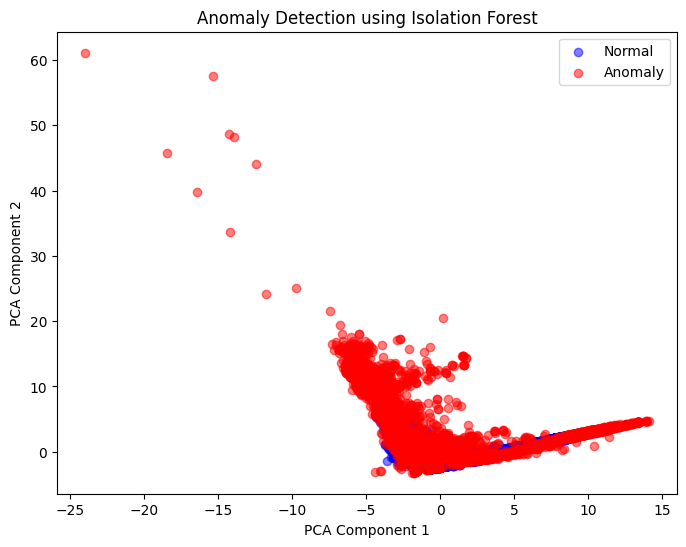

In [51]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_test_2d[y_pred == 0, 0],
    X_test_2d[y_pred == 0, 1],
    c='blue', label='Normal', alpha=0.5
)

plt.scatter(
    X_test_2d[y_pred == 1, 0],
    X_test_2d[y_pred == 1, 1],
    c='red', label='Anomaly', alpha=0.5
)

plt.legend()
plt.title("Anomaly Detection using Isolation Forest")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

#**METHOD 2 — Anomaly Score Plot (Very Professional)**

In [45]:
scores = model.decision_function(X_test)

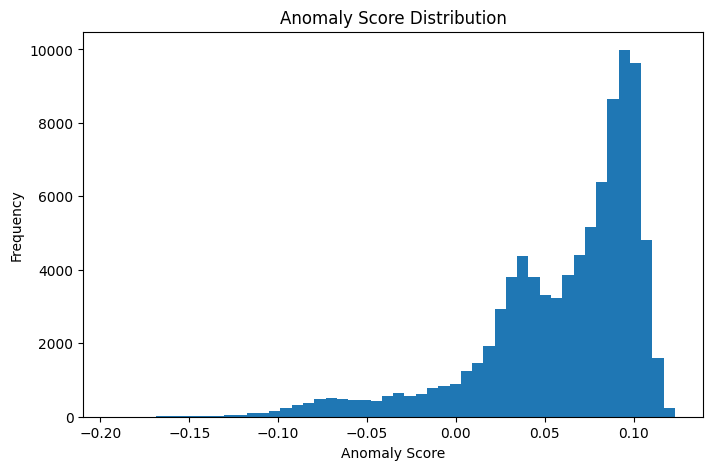

In [46]:
plt.figure(figsize=(8,5))
plt.hist(scores, bins=50)
plt.title("Anomaly Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.show()

#METHOD 3 — Time-Based Anomaly Plot (If Using Connectivity Feature)

If you want to show high connectivity spikes:

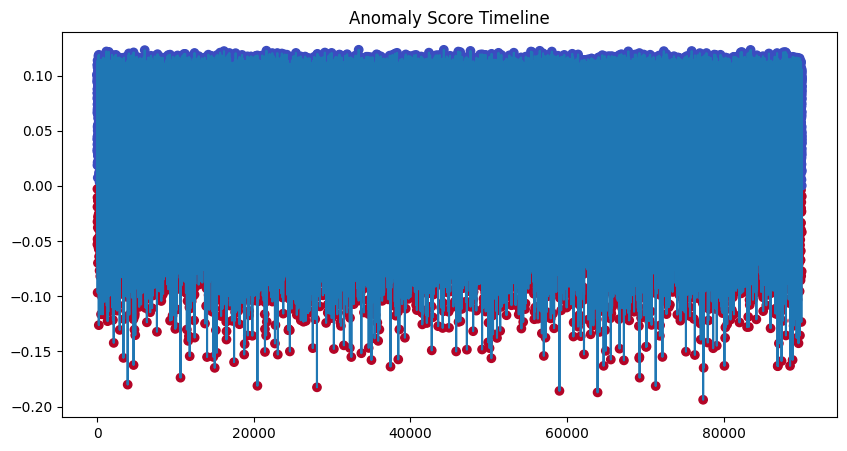

In [47]:
plt.figure(figsize=(10,5))
plt.plot(scores)
plt.scatter(
    range(len(scores)),
    scores,
    c=y_pred,
    cmap='coolwarm'
)
plt.title("Anomaly Score Timeline")
plt.show()

In [48]:
import joblib

joblib.dump(model, "isolation_forest_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']